In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
import pandas as pd
from IPython.display import HTML
import time

from numcosmo_py import Nc, Ncm, sky_match
from numcosmo_py.sky_match import (
    BestCandidates,
    Coordinates,
    DistanceMethod,
    SelectionCriteria,
    SkyMatch,
    SkyMatchResult,
)
from astropy import units as u
from numcosmo_py.plotting.tools import set_rc_params_article, confidence_ellipse
from astropy.coordinates import SkyCoord, Angle
from scipy.special import erf
set_rc_params_article(ncol=1)
Ncm.cfg_init()

Omega_b = 0.0486
Omega_c = 0.2614
Omega_k = 0.0
H0 = 67.7

#Omega_b = 0.05
#Omega_c = 0.25
#Omega_k = 0.0
#H0 = 70.0

# Create a cosmology object
cosmo = Nc.HICosmoDEXcdm.new()
cosmo.omega_x2omega_k()
cosmo["Omegab"] = Omega_b
cosmo["Omegac"] = Omega_c
cosmo["Omegak"] = Omega_k
cosmo["H0"] = H0
cosmo["w"] = -1.0

dist = Nc.Distance.new(100.0)
dist.compute_inv_comoving(True)
dist.prepare(cosmo)

# Lets fix the numpy seed to get reproducible results
np.random.seed(74682)


In [2]:
# Constants
CLUSTER_LENGTH = 100
HALO_LENGTH = 200

RA_MIN, RA_MAX = -10.0, 10.0
DEC_MIN, DEC_MAX = -10.0, 10.0
Z_MIN, Z_MAX = 0.2, 0.5
LOGM_MIN, LOGM_MAX = 13.0, 15.0  # Mass in log10 solar masses
LOGM_ADD_HALO_MIN, LOGM_ADD_HALO_MAX = 10.0, 13.0

# Generate cluster positions, redshifts, and masses
cluster_ra = np.random.uniform(RA_MIN, RA_MAX, CLUSTER_LENGTH)
cluster_sin_dec = np.random.uniform(
    np.sin(np.radians(DEC_MIN)), np.sin(np.radians(DEC_MAX)), CLUSTER_LENGTH
)
cluster_dec = np.degrees(np.arcsin(cluster_sin_dec))
cluster_z = np.random.uniform(Z_MIN, Z_MAX, CLUSTER_LENGTH)
cluster_logm = np.random.uniform(LOGM_MIN, LOGM_MAX, CLUSTER_LENGTH)
# Let's compute the cluster radii, and the 3D positions
cluster_r = np.array(dist.comoving_array(cosmo, cluster_z)) * cosmo.RH_Mpc()
cluster_x1 = (
    cluster_r * np.cos(np.radians(cluster_dec)) * np.cos(np.radians(cluster_ra))
)
cluster_x2 = (
    cluster_r * np.cos(np.radians(cluster_dec)) * np.sin(np.radians(cluster_ra))
)
cluster_x3 = cluster_r * np.sin(np.radians(cluster_dec))

# Generate halo positions, redshifts, and masses
# Lets first sample a halo < 5.0 Mpc from the cluster in each dimension
D_DIM = 5.0

halo_x1 = cluster_x1 + np.random.uniform(-D_DIM, D_DIM, CLUSTER_LENGTH)
halo_x2 = cluster_x2 + np.random.uniform(-D_DIM, D_DIM, CLUSTER_LENGTH)
halo_x3 = cluster_x3 + np.random.uniform(-D_DIM, D_DIM, CLUSTER_LENGTH)
halo_ra = np.degrees(np.arctan2(halo_x2, halo_x1))
halo_dec = np.degrees(np.arcsin(halo_x3 / cluster_r))
halo_r = np.sqrt(halo_x1**2 + halo_x2**2 + halo_x3**2)
halo_z = [dist.inv_comoving(cosmo, r / cosmo.RH_Mpc()) for r in halo_r]

# Now for the halo masses we use the cluster's masses added a Gaussian noise
halo_logm = cluster_logm + np.random.normal(0, 1.0, CLUSTER_LENGTH)

# Finally we add 100 more halos randomly
DELTA_OBJECTS = HALO_LENGTH - CLUSTER_LENGTH
halo_ra = np.append(halo_ra, np.random.uniform(RA_MIN, RA_MAX, DELTA_OBJECTS))
halo_dec = np.append(halo_dec, np.random.uniform(DEC_MIN, DEC_MAX, DELTA_OBJECTS))
halo_z = np.append(halo_z, np.random.uniform(Z_MIN, Z_MAX, DELTA_OBJECTS))
halo_logm = np.append(
    halo_logm, np.random.uniform(LOGM_ADD_HALO_MIN, LOGM_ADD_HALO_MAX, DELTA_OBJECTS)
)
halo_id = np.array([int(i + 200000) for i in range(len(halo_z))])
halos = Table([halo_id, halo_ra, halo_dec, halo_z, halo_logm], 
              names=("halo_id", "RA", "DEC", "z", "Mass"), 
              dtype=(int, float, float, float, float))

cluster_id = np.array([int(i + 100000) for i in range(len(cluster_z))])
clusters = Table([cluster_id, cluster_ra, cluster_dec, cluster_z, cluster_logm], 
              names=("cluster_id", "RA", "DEC", "z", "Mass"), 
              dtype=(int, float, float, float, float))

halo_id,RA,DEC,z,Mass
int64,float64,float64,float64,float64
200000,-5.741330417871167,-0.3411143953735255,0.42984934523315443,13.318108384141226
200001,6.5422892579006104,-8.890680617538013,0.44045266990095866,12.522369124570776
200002,6.949212384085108,9.90000397985873,0.2493043478530568,13.46164573196632
200003,4.08617506979206,7.0277821509639224,0.4528776942921649,14.18820590633073
200004,8.326080390817673,-7.898572458600389,0.36594981248122654,14.397825669900973
200005,-3.254123061955408,-5.547612076765774,0.48366934759146446,14.00467283325814
200006,2.8105446073258418,-4.144840910880551,0.410731473541052,14.61701405586647
200007,8.82772902966833,-4.390304583143103,0.24704582615954704,15.529609743628178
200008,7.245209787605854,6.276485567138811,0.24355831685873083,14.345763078594883


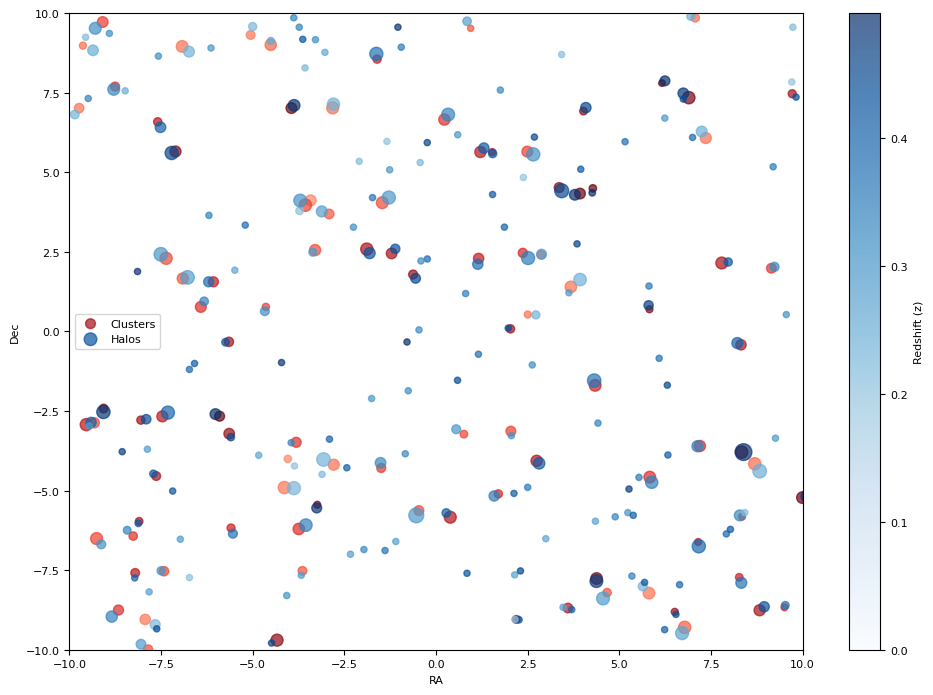

In [3]:
# Scale marker sizes with log mass
def scale_marker_size(log_mass, base_size=20, scale_factor=30):
    arr = scale_factor * (log_mass - LOGM_MIN)
    return base_size + np.where(arr < 0, 0, arr)


cluster_sizes = scale_marker_size(cluster_logm)
halo_sizes = scale_marker_size(halo_logm)

fig, ax = plt.subplots(figsize=(10, 7))

# Scatter plot for clusters (fixed red color)
ax.scatter(
    cluster_ra,
    cluster_dec,
    c=cluster_z,
    cmap="Reds",
    s=cluster_sizes,
    label="Clusters",
    alpha=0.7,
    vmin=0.0,
)

# Scatter plot for halos (color varies with z, from light to dark blue)
halo_scatter = ax.scatter(
    halo_ra,
    halo_dec,
    c=halo_z,
    cmap="Blues",
    s=halo_sizes,
    label="Halos",
    alpha=0.7,
    vmin=0.0,
)

# Colorbar to indicate redshift values
color_bar = plt.colorbar(halo_scatter, ax=ax, label="Redshift (z)")

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_xlim(RA_MIN, RA_MAX)
ax.set_ylim(DEC_MIN, DEC_MAX)
ax.legend()
plt.tight_layout()
plt.savefig("halos_clusters.pdf")
plt.show()

In [4]:
c_light = 299792.458 
def rho_crit(z):
   return  2.8*10**(11)*cosmo.h2() * ((cosmo["Omegac"]+cosmo["Omegab"])/(1+z)**3 + (1 - cosmo["Omegac"]-cosmo["Omegab"])) 

def get_galaxy_coords(ra_c, dec_c, sep_angular_rad, phi_rad):
    """
    Calcula RA e DEC de uma galáxia usando trigonometria esférica.
    
    Parâmetros:
    ra_c, dec_c: Coordenadas do centro (em graus)
    sep_angular_rad: galaxy_R / dA (em radianos)
    phi_rad: Ângulo de posição sorteado (em radianos)
    """
    
    # 1. Converter coordenadas do centro para radianos
    ra_c_rad = np.radians(ra_c)
    dec_c_rad = np.radians(dec_c)
    
    # 2. Calcular a Declinação (delta)
    # sin(delta) = sin(dec_c)cos(sep) + cos(dec_c)sin(sep)cos(phi)
    sin_dec = (np.sin(dec_c_rad) * np.cos(sep_angular_rad) + 
               np.cos(dec_c_rad) * np.sin(sep_angular_rad) * np.cos(phi_rad))
    
    dec_gal_rad = np.arcsin(sin_dec)
    
    # 3. Calcular a Ascensão Reta (alpha)
    # Usamos o termo y e x para o arctan2(y, x)
    y = np.sin(phi_rad) * np.sin(sep_angular_rad) * np.cos(dec_c_rad)
    x = np.cos(sep_angular_rad) - np.sin(dec_c_rad) * np.sin(dec_gal_rad)
    
    ra_gal_rad = ra_c_rad + np.arctan2(y, x)
    
    # 4. Converter de volta para graus e normalizar o RA para [0, 360]
    ra_gal = np.degrees(ra_gal_rad) % 360
    dec_gal = np.degrees(dec_gal_rad)
    
    return ra_gal, dec_gal

def HOD_model(m_halo, logMmin=12.72, sigma_logM=0.26, alpha=1.15, logM1=13.93, logM0=12.7):
    """
    Standard HOD model (Zheng et al. 2007)
    Returns number of centrals (0 or 1) and satellites (int)
    """
    # 1. Mean Central Occupancy (Error function)
    from scipy.special import erf
    mean_n_cen = 0.5 * (1 + erf((np.log10(m_halo) - logMmin) / sigma_logM))
    n_cen = 1 if np.random.random() < mean_n_cen else 0
    
    # 2. Mean Satellite Occupancy (Power Law)
    n_sat = 0
    if n_cen == 1:
        # Satellites only exist if a central exists
        diff = m_halo - 10**logM0
        mean_n_sat = (np.maximum(0, diff) / 10**logM1)**alpha
        if mean_n_sat > 0:
            n_sat = np.random.poisson(mean_n_sat)
            
    return n_cen, n_sat

In [5]:
halo_mass = 10**(halos['Mass'])
cluster_mass = 10**(clusters['Mass'])
halos['R200'] = ((3*(halo_mass))/(4*np.pi* 200*(rho_crit(halos['z']))))**(1/3)
clusters['R200'] = ((3*(cluster_mass))/(4*np.pi* 200*(rho_crit(clusters['z']))))**(1/3)

# Creating halo galaxy catalogs

In [6]:
np.random.seed(74682)
all_galaxies = []

for i in range(len(halos)):
    n_cen, n_sat = HOD_model(10**halos['Mass'][i])
    total_gals = n_cen + n_sat
    if total_gals == 0:
        continue
        
    # Generate local coordinates
    # Central is at (0,0,0), Satellites follow NFW/Uniform profile
    galaxy_R = np.zeros(total_gals)
    if n_sat > 0:
        # Satellites distributed within R200
        galaxy_R[n_cen:] = halos['R200'][i] * np.random.uniform(0, 1, n_sat)**(1/3)

    h_ra = halos['RA'][i]
    h_dec = halos['DEC'][i]
    h_z = halos['z'][i]
    h_r200 = halos['R200'][i]

    galaxy_R = h_r200 * np.random.uniform(0, 1, total_gals)**(1/3)
    costheta = np.random.uniform(-1, 1, total_gals)
    galaxy_theta = np.arccos(costheta)
    galaxy_phi = np.random.uniform(0, 2*np.pi, total_gals)

    Hz = cosmo.H(h_z)

    distancia_radial = galaxy_R * np.cos(galaxy_theta) 
    delta_z = (Hz / c_light) * distancia_radial
    z_galaxy = h_z + delta_z


    dA = dist.angular_diameter(cosmo, h_z) * cosmo.RH_Mpc()
    sep_angular = galaxy_R / dA 

    ra_g, dec_g = get_galaxy_coords(h_ra, h_dec, sep_angular, galaxy_phi)

    ra_corrected = ra_g % 360.0
    
    ra_corrected = np.where(ra_corrected > 180, ra_corrected - 360, ra_corrected)
    
    ra_corrected = np.clip(ra_corrected, RA_MIN, RA_MAX)
    
    
    temp_table = Table()

    temp_table['halo_id'] = np.full(total_gals, i + 200000)
    temp_table['RA'] = ra_corrected
    temp_table['DEC'] = dec_g
    temp_table['z'] = z_galaxy
    temp_table['is_central'] = [True if j < n_cen else False for j in range(total_gals)]
    temp_table['halo_RA']  = np.full(total_gals, h_ra)
    temp_table['halo_DEC'] = np.full(total_gals, h_dec)
    temp_table['halo_z']   = np.full(total_gals, h_z)
    temp_table['halo_mass']   = np.full(total_gals, halos['Mass'][i])
    
    all_galaxies.append(temp_table)

if all_galaxies:
    galaxy_halo_catalog = vstack(all_galaxies)
    galaxy_halo_catalog['galaxy_id'] = np.arange(len(galaxy_halo_catalog))
    
    # Reorder columns for readability
    ordered_cols = ['galaxy_id', 'halo_id', 'is_central', 'RA', 'DEC', 'z', 'halo_z', 'halo_mass']
    galaxy_halo_catalog = galaxy_halo_catalog[ordered_cols]
    
    print(f"Generated {len(galaxy_halo_catalog)} galaxies from {len(halos)} halos.")
    display(galaxy_halo_catalog[:10]) # Show first 10 rows
else:
    print("No galaxies were generated. Check your HOD mass thresholds.")

Generated 7074 galaxies from 200 halos.


galaxy_id,halo_id,is_central,RA,DEC,z,halo_z,halo_mass
int64,int64,bool,float64,float64,float64,float64,float64
0,200000,True,-5.75603704469421,-0.3167717479601696,0.429917256371976,0.42984934523315443,13.318108384141226
1,200002,True,6.919921080659926,9.911025868721861,0.2492246606212074,0.2493043478530568,13.46164573196632
2,200002,False,6.957413482708001,9.907684676774473,0.2492714035682601,0.2493043478530568,13.46164573196632
3,200002,False,6.909757016562465,9.891826829645346,0.24924599169917805,0.2493043478530568,13.46164573196632
4,200003,True,4.080715920848293,7.041786045903547,0.4528251335526976,0.4528776942921649,14.18820590633073
5,200003,False,4.120353961975129,7.0646451745453085,0.4526226588298956,0.4528776942921649,14.18820590633073
6,200003,False,4.0645061095718376,7.0061308171522345,0.45290669046519166,0.4528776942921649,14.18820590633073
7,200003,False,4.126634813840513,7.02323023223861,0.45279497712638084,0.4528776942921649,14.18820590633073
8,200003,False,4.131770392319192,7.007229836118845,0.45264361773630646,0.4528776942921649,14.18820590633073


# Creating cluster galaxy catalog

In [7]:
np.random.seed(74682)
all_galaxies = []

for i in range(len(clusters)):
    n_cen, n_sat = HOD_model(10**clusters['Mass'][i])
    
    total_gals = n_cen + n_sat
    if total_gals == 0:
        continue
        
    # Generate local coordinates
    # Central is at (0,0,0), Satellites follow NFW/Uniform profile
    galaxy_R = np.zeros(total_gals)
    if n_sat > 0:
        # Satellites distributed within R200
        galaxy_R[n_cen:] = clusters['R200'][i] * np.random.uniform(0, 1, n_sat)**(1/3)

    c_ra = clusters['RA'][i]
    c_dec = clusters['DEC'][i]
    c_z = clusters['z'][i]
    c_r200 = clusters['R200'][i]

    galaxy_R = c_r200 * np.random.uniform(0, 1, total_gals)**(1/3)
    costheta = np.random.uniform(-1, 1, total_gals)
    galaxy_theta = np.arccos(costheta)
    galaxy_phi = np.random.uniform(0, 2*np.pi, total_gals)

    Hz = cosmo.H(c_z)

    distancia_radial = galaxy_R * np.cos(galaxy_theta) 
    delta_z = (Hz / c_light) * distancia_radial
    z_galaxy = c_z + delta_z


    dA = dist.angular_diameter(cosmo, c_z) * cosmo.RH_Mpc()
    sep_angular = galaxy_R / dA 

    ra_g, dec_g = get_galaxy_coords(c_ra, c_dec, sep_angular, galaxy_phi)

    ra_corrected = ra_g % 360.0
    
    ra_corrected = np.where(ra_corrected > 180, ra_corrected - 360, ra_corrected)
    
    ra_corrected = np.clip(ra_corrected, RA_MIN, RA_MAX)
    
    
    temp_table = Table()

    temp_table['cluster_id']  = np.full(total_gals, i + 100000)
    temp_table['RA'] = ra_corrected
    temp_table['DEC'] = dec_g
    temp_table['z'] = z_galaxy
    temp_table['is_central'] = [True if j < n_cen else False for j in range(total_gals)]
    temp_table['cluster_RA']  = np.full(total_gals, h_ra)
    temp_table['cluster_DEC'] = np.full(total_gals, h_dec)
    temp_table['cluster_z']   = np.full(total_gals, h_z)
    temp_table['cluster_mass']   = np.full(total_gals, clusters['Mass'][i])
    
    all_galaxies.append(temp_table)

if all_galaxies:
    galaxy_cluster_catalog = vstack(all_galaxies)
    galaxy_cluster_catalog['galaxy_id'] = np.arange(len(galaxy_cluster_catalog))
    
    # Reorder columns for readability
    ordered_cols = ['galaxy_id', 'cluster_id', 'is_central', 'RA', 'DEC', 'z', 'cluster_z','cluster_mass']
    galaxy_cluster_catalog = galaxy_cluster_catalog[ordered_cols]
    
    print(f"Generated {len(galaxy_cluster_catalog)} galaxies from {len(clusters)} clusters.")
    display(galaxy_cluster_catalog[:10]) # Show first 10 rows
else:
    print("No galaxies were generated. Check your HOD mass thresholds.")

Generated 447 galaxies from 100 clusters.


galaxy_id,cluster_id,is_central,RA,DEC,z,cluster_z,cluster_mass
int64,int64,bool,float64,float64,float64,float64,float64
0,100000,True,-5.623863257810001,-0.29477307127856534,0.4302232300952835,0.3390733335703794,13.83167976911361
1,100000,False,-5.610638591651991,-0.34192454738287836,0.43009476144508607,0.3390733335703794,13.83167976911361
2,100000,False,-5.688649034936702,-0.3135828182191744,0.43038338535403003,0.3390733335703794,13.83167976911361
3,100000,False,-5.625003281580405,-0.3052619089501261,0.43019342895418117,0.3390733335703794,13.83167976911361
4,100001,True,6.493712952948869,-8.799172605041711,0.4400864989951944,0.3390733335703794,13.199883476688967
5,100002,True,7.0850365735336345,9.816786002611044,0.24816360693121736,0.3390733335703794,13.546044594107272
6,100003,True,4.040732973281721,6.901178000474577,0.45294040818526965,0.3390733335703794,13.323975908444126
7,100004,True,8.282978148671512,-7.732306830670557,0.3644801532716659,0.3390733335703794,13.323962416294307
8,100005,True,-3.2243552508284097,-5.452683821592189,0.48440981337217076,0.3390733335703794,13.152706843017286


# Matching by ID

In [8]:
# relabel galaxy_ids to sincronize galaxies common to halo and cluster
def relabel_synchronized_ids(catalog, id_column, offset):
    # 1. Extract the base index (e.g., 100005 -> 5)
    base_indices = catalog[id_column] - offset
    
    # 2. Identify the position of each galaxy within its group
    # We group by the base index and enumerate the rows
    group_internal_idx = np.zeros(len(catalog), dtype=int)
    unique_bases = np.unique(base_indices)
    
    for base in unique_bases:
        mask = (base_indices == base)
        # Assign 0, 1, 2... to galaxies within this specific cluster/halo
        group_internal_idx[mask] = np.arange(np.sum(mask))
    
    # 3. Create a unique, synchronized galaxy_id
    # We use a multiplier (e.g., 1000) to ensure the ID is unique
    # Formula: (Base Index * 1000) + Position_in_group
    catalog['galaxy_id'] = (base_indices * 1000) + group_internal_idx
    
    return catalog

# Apply to Cluster Catalog (Offset 100,000)
galaxy_cluster_catalog = relabel_synchronized_ids(
    galaxy_cluster_catalog, 'cluster_id', 100000
)

# Apply to Halo Catalog (Offset 200,000)
galaxy_halo_catalog = relabel_synchronized_ids(
    galaxy_halo_catalog, 'halo_id', 200000
)

In [9]:
halo_coordinates = {"RA":"RA" , "DEC":"DEC" , "z":"z"}
halo_ids  = {"ID": "halo_id", "MemberID": "galaxy_id"}

detections_coordinates =  {"RA":"RA" , "DEC":"DEC" , "z":"z"}
detections_ids  = {"ID": "cluster_id", "MemberID": "galaxy_id"}


halos_m = sky_match.SkyMatch(
    query_data= halos,
    query_coordinates=halo_coordinates,
    query_member_data=galaxy_halo_catalog,
    query_ids = halo_ids, 
    match_data=clusters,
    match_coordinates=detections_coordinates,
    match_member_data=galaxy_cluster_catalog,
    match_ids = detections_ids
)

detections_m = halos_m.invert_query_match()

In [10]:
%time halos_matched = halos_m.match_ID()
%time best_halos = halos_matched.select_best()
%time best_halos_table = halos_matched.to_table_best(best_halos)

CPU times: user 18.1 ms, sys: 1.41 ms, total: 19.5 ms
Wall time: 18.8 ms
CPU times: user 11.5 ms, sys: 116 μs, total: 11.6 ms
Wall time: 11.6 ms
CPU times: user 428 μs, sys: 0 ns, total: 428 μs
Wall time: 432 μs


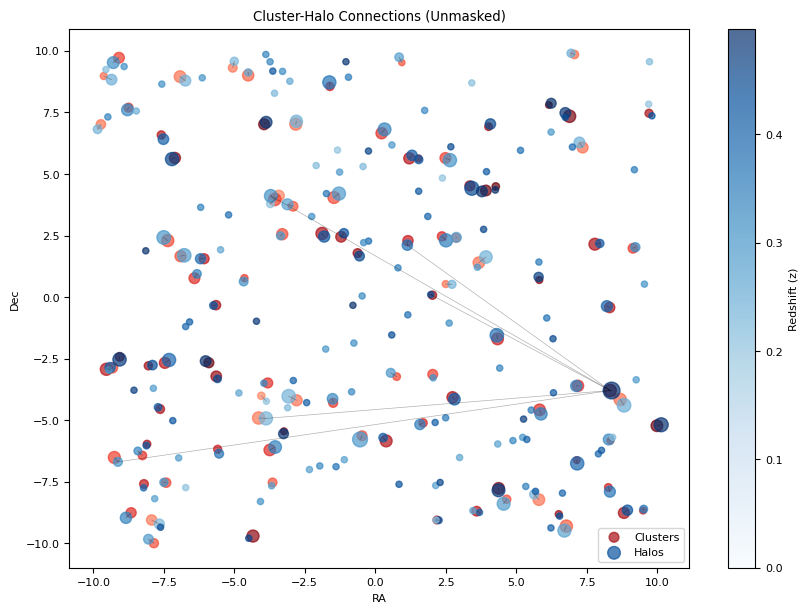

In [11]:
def plot_no_mask():
    fig, ax = plt.subplots(figsize=(10, 7))

    # Scatter plot for clusters (fixed red color)
    ax.scatter(
        cluster_ra,
        cluster_dec,
        c=cluster_z,
        cmap="Reds",
        s=cluster_sizes,
        label="Clusters",
        alpha=0.7,
        vmin=0.0,
    )

    # Scatter plot for halos (color varies with z, from light to dark blue)
    halo_scatter = ax.scatter(
        halo_ra,
        halo_dec,
        c=halo_z,
        cmap="Blues",
        s=halo_sizes,
        label="Halos",
        alpha=0.7,
        vmin=0.0,
    )

    # Plot lines connecting clusters to ALL matched halos (no mask filtering)
    # idx contains the indices of the nearest neighbors for each cluster
    for i, idx in enumerate(halos_matched.nearest_neighbours_indices):

        for halo_i in idx:
            if halo_i is None:
                continue
            halo_pos = halo_i - 100000
            ax.plot(
                [cluster_ra[i], halo_ra[halo_pos]],
                [cluster_dec[i], halo_dec[halo_pos]],
                color="black",
                alpha=0.3, # Lower alpha helps if lines are very dense
                linewidth=0.5
            )

    ax.legend()

    # Colorbar to indicate redshift values
    color_bar = plt.colorbar(halo_scatter, ax=ax, label="Redshift (z)")

    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")
    ax.set_title("Cluster-Halo Connections (Unmasked)")

    return fig

# Execute the plot
plot_no_mask()
plt.show()

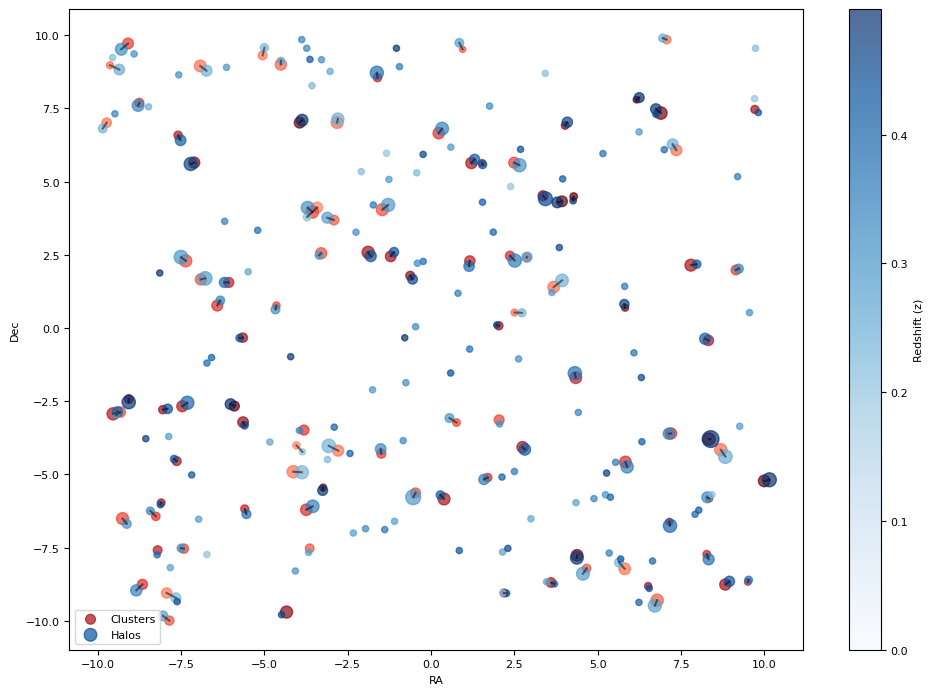

In [12]:
def plot_best():
    fig, ax = plt.subplots(figsize=(10, 7))

    # Scatter plot for clusters (fixed red color)
    ax.scatter(
        cluster_ra,
        cluster_dec,
        c=cluster_z,
        cmap="Reds",
        s=cluster_sizes,
        label="Clusters",
        alpha=0.7,
        vmin=0.0,
    )

    # Scatter plot for halos (color varies with z, from light to dark blue)
    halo_scatter = ax.scatter(
        halo_ra,
        halo_dec,
        c=halo_z,
        cmap="Blues",
        s=halo_sizes,
        label="Halos",
        alpha=0.7,
        vmin=0.0,
    )

    # Plot lines connecting clusters to ALL matched halos (no mask filtering)
    # idx contains the indices of the nearest neighbors for each cluster
    for cluster_i, halo_i in zip(best_halos.query_indices, best_halos.indices):
        ax.plot(
            [cluster_ra[cluster_i], halo_ra[halo_i]],
            [cluster_dec[cluster_i], halo_dec[halo_i]],
            color="black",
            alpha=0.5,
        )

    ax.legend()

    # Colorbar to indicate redshift values
    color_bar = plt.colorbar(halo_scatter, ax=ax, label="Redshift (z)")

    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")
    plt.tight_layout()
    return fig

    return fig

# Execute the plot
plot_best()
plt.show()